In [8]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
customers_schema = {"Customer_Id" :pl.Int64,
                    "Name": pl.String,
                    "Last_Name": pl.String,
                    "Gender" : pl.Boolean,
                    "Birth_Date" : pl.Date,
                    "Latitude": pl.Float32,
                    "Longitude" : pl.Float32,
                    "Zipcode" : pl.Int64 ,
                    "Email" : pl.String,
                    "Phone_Number" : pl.String,
                    "Created_At" : pl.Date,
                    "Status" : pl.String,
                    "Profile_Type" : pl.String,
                    "Updated_At" : pl.Datetime}


payments_schema = {"Payment_Id" : pl.String,
                    "Plan_Id" : pl.Int64,
                    "Customer_Id" : pl.Int64,
                    "Payment_Amount" : pl.Float32,
                    "Payment_Time" : pl.Datetime,
                    "Plan_Expiration_Time" : pl.Datetime,
                    "Payment_Status": pl.String,
                    "Updated_At" : pl.Datetime
}

access_schema = {"Visit_Id" : pl.Int64,
                    "Customer_Id" : pl.Int64,
                    "Plan_Id" : pl.Int64,
                    "Branch_Id" : pl.Int8,
                    "Payment_Id" : pl.String,
                    "Date" : pl.Date,
                    "Visit_Time" : pl.Datetime,
                    "Updated_At" : pl.Datetime
}

In [3]:
# df_cus_old = pl.read_csv("../data copy/customers_v2.csv", schema = customers_schema)
df_cus =  pl.read_csv("../data/customers_v2.csv", schema = customers_schema)

df_access_old = pl.read_csv("../data copy/access_v2.csv", schema = access_schema)
df_access =  pl.read_csv("../data/access_v2.csv", schema = access_schema)

df_pay_old = pl.read_csv("../data copy/payments_v2.csv", schema = payments_schema)
df_pay =  pl.read_csv("../data/payments_v2.csv", schema = payments_schema)

In [4]:
df_cus

Customer_Id,Name,Last_Name,Gender,Birth_Date,Latitude,Longitude,Zipcode,Email,Phone_Number,Created_At,Status,Profile_Type,Updated_At
i64,str,str,bool,date,f32,f32,i64,str,str,date,str,str,datetime[μs]
1,"""Ernesto Silvano""","""Arroyo Mora""",true,2000-12-18,21.024862,-101.25441,36013,"""z************m@hotmail.com""","""(473)7977952""",2026-02-01,"""Active""","""3""",2026-06-01 21:40:09.390294
2,"""Óliver Mauricio""","""Saiz de la Garza""",true,2004-08-20,21.017761,-101.254082,36000,"""r********g@gmail.com""","""(473)7554933""",2026-02-01,"""Active""","""1""",2026-06-01 21:40:12.797359
3,"""Eva Amalia""","""Flores Rangel""",false,2000-07-09,21.002136,-101.257401,36080,"""v*********h@gmail.com""","""(473)3150401""",2026-02-01,"""Active""","""1""",2026-06-01 21:40:16.135513
4,"""Joaquín Alejandro""","""Mercado Espinoza""",true,2006-05-28,21.03986,-101.247597,36023,"""e**********o@gmail.com""","""(473)1597298""",2026-02-01,"""Active""","""5""",2026-06-01 21:40:19.694481
5,"""Dulce Tania""","""Villaseñor Echeverría""",false,1972-09-03,21.018347,-101.249214,36003,"""t********l@gmail.com""","""(473)1420050""",2026-02-01,"""Active""","""1""",2026-06-01 21:40:23.149214
…,…,…,…,…,…,…,…,…,…,…,…,…,…
47,"""Teresa Eugenia""","""Ordóñez Gálvez""",false,2002-01-16,21.022772,-101.237778,36093,"""v*********u@gmail.com""","""(473)9350054""",2026-05-27,"""Active""","""8""",2026-06-01 21:42:43.289621
48,"""Felix René""","""Reyes Covarrubias""",true,2005-09-13,20.96137,-101.279083,36259,"""k*********y@hotmail.com""","""(473)3671901""",2026-05-27,"""Active""","""2""",2026-06-01 21:42:46.862664
49,"""Sofía Nadia""","""Alba Herrera""",false,2006-06-15,21.03676,-101.256516,36023,"""u*************i@gmail.com""","""(473)7941183""",2026-05-29,"""Active""","""2""",2026-06-01 21:42:50.318468


In [ ]:
# Create customers_cleaned
# Get age, change gender label, mask phone number

# Create access_cleaned 
# Add cronological index, add day name, add week number, 

# Payments_Cleaned
# Get number of payment from id, create payment date

# Gold
# Create a full TAD for data scientist 

In [6]:
df_access_old

Visit_Id,Customer_Id,Plan_Id,Branch_Id,Payment_Id,Date,Visit_Time,Updated_At
i64,i64,i64,i8,str,date,datetime[μs],datetime[μs]
1,1,1,1,"""1-1""",2026-02-01,2026-02-01 19:45:11,2026-02-01 19:45:11
2,2,1,1,"""2-1""",2026-02-01,2026-02-01 06:19:00,2026-02-01 06:19:00
3,3,1,1,"""3-1""",2026-02-01,2026-02-01 06:53:56,2026-02-01 06:53:56
4,4,1,1,"""4-1""",2026-02-01,2026-02-01 17:11:39,2026-02-01 17:11:39
5,5,1,1,"""5-1""",2026-02-01,2026-02-01 07:08:30,2026-02-01 07:08:30
…,…,…,…,…,…,…,…
1629,41,3,1,"""41-3""",2026-05-30,2026-05-30 17:20:47,2026-05-30 17:20:47
1630,42,1,1,"""42-8""",2026-05-30,2026-05-30 10:03:25,2026-05-30 10:03:25
1631,43,1,1,"""43-2""",2026-05-30,2026-05-30 14:18:15,2026-05-30 14:18:15


In [7]:
df_access

Visit_Id,Customer_Id,Plan_Id,Branch_Id,Payment_Id,Date,Visit_Time,Updated_At
i64,i64,i64,i8,str,date,datetime[μs],datetime[μs]
1,1,1,1,"""1-1""",2026-02-01,2026-02-01 19:45:11,2026-02-01 19:45:11
2,2,1,1,"""2-1""",2026-02-01,2026-02-01 06:19:00,2026-02-01 06:19:00
3,3,1,1,"""3-1""",2026-02-01,2026-02-01 06:53:56,2026-02-01 06:53:56
4,4,1,1,"""4-1""",2026-02-01,2026-02-01 17:11:39,2026-02-01 17:11:39
5,5,1,1,"""5-1""",2026-02-01,2026-02-01 07:08:30,2026-02-01 07:08:30
…,…,…,…,…,…,…,…
1710,42,1,1,"""42-10""",2026-06-03,2026-06-03 08:56:56,2026-06-03 08:56:56
1711,45,2,1,"""45-2""",2026-06-03,2026-06-03 13:55:57,2026-06-03 13:55:57
1712,48,3,1,"""48-2""",2026-06-03,2026-06-03 11:41:13,2026-06-03 11:41:13


In [8]:
temp_payments = df_pay.join(df_pay_old, on = ["Payment_Id"], how = "full")

In [9]:
temp_payments = temp_payments.select(df_pay.columns + ["Payment_Id_right"]).filter(pl.col("Payment_Id_right").is_null()).drop("Payment_Id_right")
temp_payments

Payment_Id,Plan_Id,Customer_Id,Payment_Amount,Payment_Time,Plan_Expiration_Time,Payment_Status,Updated_At
str,i64,i64,f32,datetime[μs],datetime[μs],str,datetime[μs]
"""50-1""",1,50,150.0,2026-05-31 19:08:40,2026-05-31 23:59:59,"""Completed""",2026-05-31 19:08:40
"""51-1""",1,51,150.0,2026-05-31 06:37:22,2026-05-31 23:59:59,"""Completed""",2026-05-31 06:37:22
"""6-15""",1,6,150.0,2026-06-01 10:05:18,2026-06-01 23:59:59,"""Completed""",2026-06-01 10:05:18
"""11-19""",1,11,150.0,2026-06-01 09:48:06,2026-06-01 23:59:59,"""Completed""",2026-06-01 09:48:06
"""21-10""",1,21,150.0,2026-06-01 14:20:34,2026-06-01 23:59:59,"""Completed""",2026-06-01 14:20:34
…,…,…,…,…,…,…,…
"""50-2""",3,50,1200.0,2026-06-02 19:07:50,2026-07-01 23:59:59,"""Completed""",2026-06-02 19:07:50
"""51-2""",4,51,10000.0,2026-06-02 06:40:32,2027-06-01 23:59:59,"""Completed""",2026-06-02 06:40:32
"""10-21""",1,10,150.0,2026-06-03 14:18:08,2026-06-03 23:59:59,"""Completed""",2026-06-03 14:18:08


In [10]:
df_pay.select(pl.sum("Payment_Amount"))

Payment_Amount
f32
298750.0


In [11]:
df_pay.group_by("Customer_Id").agg(pl.len(), pl.sum("Payment_Amount"))

Customer_Id,len,Payment_Amount
i64,u32,f32
51,2,10150.0
45,2,800.0
34,2,10150.0
42,10,1500.0
35,5,1750.0
…,…,…
39,2,1350.0
16,4,11500.0
3,3,11350.0


In [14]:
ts = df_pay.with_columns(pl.col("Payment_Time").cast(pl.Date).alias("Payment_Date")).group_by("Payment_Date").agg(pl.len(), pl.sum("Payment_Amount")).sort(by = ["Payment_Date"])

In [15]:
ts

Payment_Date,len,Payment_Amount
date,u32,f32
2026-02-01,12,1800.0
2026-02-02,5,3900.0
2026-02-03,4,31200.0
2026-02-04,2,1350.0
2026-02-05,2,1350.0
…,…,…
2026-05-30,7,1550.0
2026-05-31,2,300.0
2026-06-01,3,450.0


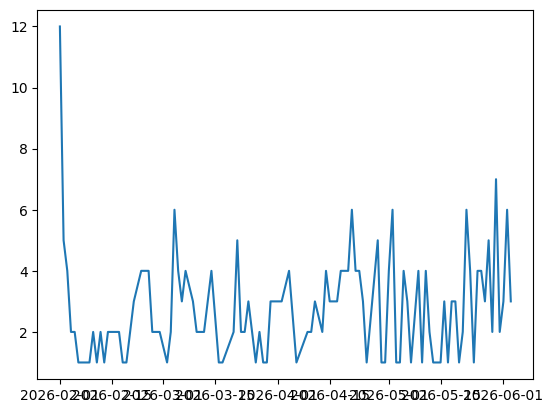

In [ ]:
plt.plot(ts["Payment_Date"], ts["len"])

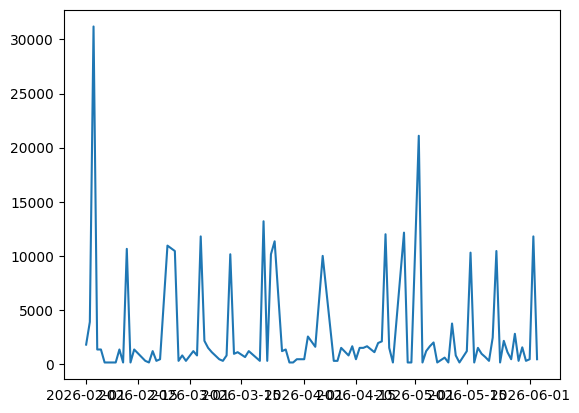

In [18]:
plt.plot(ts["Payment_Date"], ts["Payment_Amount"])

In [24]:
ts_access = df_access.group_by("Date").agg(pl.len())

In [25]:
ts_access

Date,len
date,u32
2026-02-02,5
2026-02-06,10
2026-02-09,6
2026-04-25,25
2026-02-25,13
…,…
2026-02-14,8
2026-03-14,15
2026-03-22,2


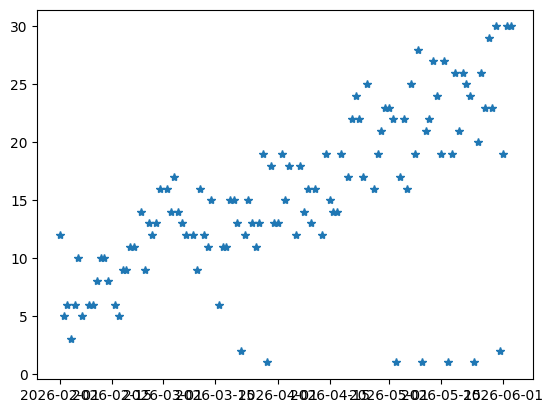

In [27]:
plt.plot(ts_access["Date"], ts_access["len"], '*')

In [13]:
# def haversine(lon1, lat1, lon2, lat2):
#     """
#     Calculate the great circle distance in kilometers between two points 
#     on the earth (specified in decimal degrees)
#     """
#     # convert decimal degrees to radians 
#     lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

#     # haversine formula 
#     dlon = lon2 - lon1 
#     dlat = lat2 - lat1 
#     a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
#     c = 2 * asin(sqrt(a)) 
#     r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
#     return c * r